# Notebook with examples of clustering based on trajectories information 

This notebook gives examples on how the data can be used to perform clustering. Kmeans and Agglomerative Clustering are performed. The data used for this code is the semantic information of entire trajectories. 

### Kmeans Clustering

In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn import metrics
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [62]:
#File with information about trajectories
df_trajs=pd.read_csv("../data/semantic_info_entire_trajectories.csv")
df_trajs.head()

,trajectory_id,duration,speed,nb_items,nb_stops,length,distwall,curvature
0,201902181020,3704.0,17.244834,116.0,56,63729.789580,186.948068,0.038783
1,201902181200,2948.0,32.334112,95.0,42,95257.544128,167.649512,0.174906
2,201902181210,2948.0,32.793737,96.0,39,96566.818958,171.266685,0.144522
3,201902181410,3696.0,24.988200,237.0,79,92159.278191,166.745664,0.029800
4,201902181600,4836.0,18.148534,196.0,92,87735.324794,209.252325,0.111875


In [63]:
df_trajs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   trajectory_id  51 non-null     int64  
 1   duration       51 non-null     float64
 2   speed          51 non-null     float64
 3   nb_items       51 non-null     float64
 4   nb_stops       51 non-null     int64  
 5   length         51 non-null     float64
 6   distwall       51 non-null     float64
 7   curvature      51 non-null     float64
dtypes: float64(6), int64(2)
memory usage: 3.3 KB


In [64]:
#Finding outliers and remove them
z_scores = np.abs(zscore(df_trajs.drop(["trajectory_id"], axis=1))) 
outliers = (z_scores > 3).any(axis=1)
df_trajs_outliers = df_trajs[outliers]   
df_trajs_outliers

,trajectory_id,duration,speed,nb_items,nb_stops,length,distwall,curvature
5,201902181610,1026.0,61.324044,51.0,6,62672.589918,162.552420,0.010903
6,201902201020,674.0,37.911364,9.0,11,25413.725523,157.159189,0.388117
22,201902221410,4428.0,15.147104,179.0,71,66855.049385,224.150002,0.577734


In [65]:
df_trajs=df_trajs[(df_trajs.trajectory_id!=201902201020)&(df_trajs.trajectory_id!=201902181610)&(df_trajs.trajectory_id!=201902221410)]

In [66]:
df_trajs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48 entries, 0 to 50
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   trajectory_id  48 non-null     int64  
 1   duration       48 non-null     float64
 2   speed          48 non-null     float64
 3   nb_items       48 non-null     float64
 4   nb_stops       48 non-null     int64  
 5   length         48 non-null     float64
 6   distwall       48 non-null     float64
 7   curvature      48 non-null     float64
dtypes: float64(6), int64(2)
memory usage: 3.4 KB


In [67]:
#Observing the influence of each variable with PCA
scaler = StandardScaler()
X_standardise = scaler.fit_transform(df_trajs.drop(["trajectory_id"],axis=1))

pca = PCA(n_components=3)  
X_pca = pca.fit_transform(X_standardise)

print("\nVariance explained by each principal component:")
print(pca.explained_variance_ratio_)

cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)
print("Cumulative explained variance:")
print(cumulative_explained_variance)


Variance explained by each principal component:
[0.40920037 0.24170818 0.17302359]
Cumulative explained variance:
[0.40920037 0.65090855 0.82393214]


In [68]:
features = df_trajs.drop("trajectory_id", axis=1).columns
loadings = pd.DataFrame(pca.components_, columns=features, index=[f'PC{i+1}' for i in range(len(pca.components_))])

print("Contribution of each variable to each component")
print(loadings.loc[['PC1', 'PC2', 'PC3']])

Contribution of each variable to each component
     duration     speed  nb_items  nb_stops    length  distwall  curvature
PC1  0.559535 -0.372929  0.372059  0.557499  0.303036 -0.038430   0.072832
PC2 -0.160674  0.540693  0.513435 -0.025475  0.486387  0.320915  -0.279307
PC3  0.071539  0.277174 -0.086836 -0.204121  0.474339 -0.447967   0.665717


In [69]:
#Keeping only the best variables
scaler = StandardScaler()
data=df_trajs.drop(["trajectory_id", "distwall", "curvature"],axis=1).values
data = scaler.fit_transform(data)

d:\programFiles\Anaconda\envs\env_alternance\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\programFiles\Anaconda\envs\env_alternance\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\programFiles\Anaconda\envs\env_alternance\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\programFiles\Anaconda\envs\env_alternance\Lib\site-packages\sklearn\clust

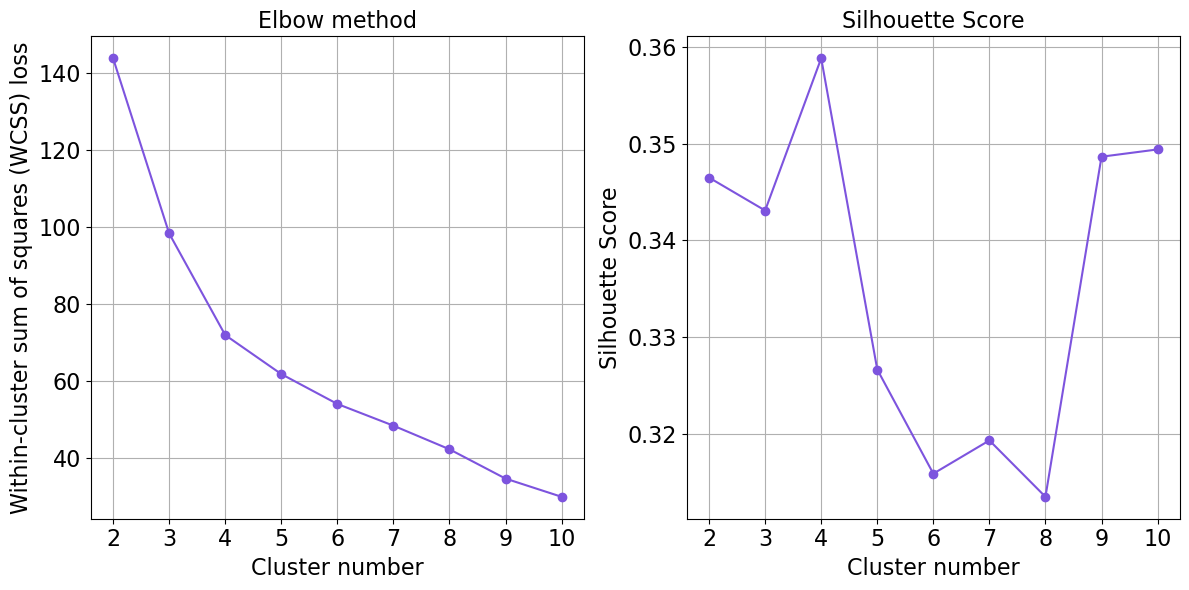

In [70]:
#Performing Kmeans and using elbow method and silhouette to choose the number of clusters

inertias = []
silhouette_scores = []

k_range=range(2,11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=40)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)
    silhouette_avg = silhouette_score(data, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker='o', color="#7d54de")
plt.title('Elbow method', fontsize=16)
plt.xlabel('Cluster number',fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel('Within-cluster sum of squares (WCSS) loss',fontsize=16)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='#7d54de')
plt.title('Silhouette Score',fontsize=16)
plt.xlabel('Cluster number',fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel('Silhouette Score',fontsize=16)
plt.grid(True)

plt.tight_layout()
plt.show()

d:\programFiles\Anaconda\envs\env_alternance\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


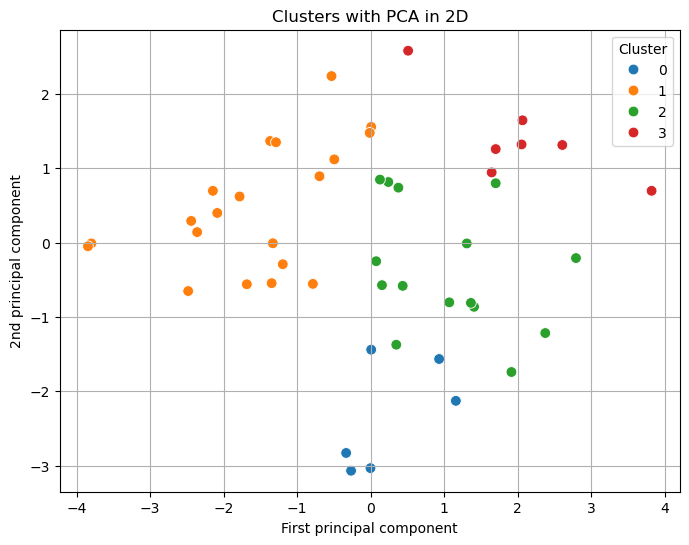

In [71]:
kmeans = KMeans(n_clusters=4)
labels = kmeans.fit_predict(data)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1],
    hue=labels,
    palette="tab10",
    s=60
)
plt.title("Clusters with PCA in 2D")
plt.xlabel("First principal component")
plt.ylabel("2nd principal component")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

In [72]:
scaler.inverse_transform(kmeans.cluster_centers_)

array([[4.03766667e+03, 1.55158359e+01, 9.56666667e+01, 5.75000000e+01,
        6.20468784e+04],
       [2.62650000e+03, 3.16268319e+01, 1.24400000e+02, 3.96000000e+01,
        8.27373259e+04],
       [3.98173333e+03, 2.14074095e+01, 1.57933333e+02, 7.00666667e+01,
        8.37206066e+04],
       [4.39600000e+03, 2.57686064e+01, 2.19142857e+02, 7.45714286e+01,
        1.11206191e+05]])

In [73]:
#Indexes (Davies-Bouldin / Calinski-Harabasz)
for i in range (2,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(data)
    labels=kmeans.labels_
    db_index = metrics.davies_bouldin_score(data, labels)
    print("Davies-Bouldin Index for "+str(i) +" groups:", db_index)
    ch_index=metrics.calinski_harabasz_score(data, labels)
    print("Calinski-Harabasz Index for "+str(i)+" groups:", ch_index)

Davies-Bouldin Index for 2 groups: 1.0631409306858097
Calinski-Harabasz Index for 2 groups: 30.54731939493372
Davies-Bouldin Index for 3 groups: 1.0205195488427938
Calinski-Harabasz Index for 3 groups: 32.40933313660856
Davies-Bouldin Index for 4 groups: 0.9382184361952549
Calinski-Harabasz Index for 4 groups: 31.34228965096421
Davies-Bouldin Index for 5 groups: 0.9980158739153728
Calinski-Harabasz Index for 5 groups: 29.00601945692543
Davies-Bouldin Index for 6 groups: 1.021753751574179
Calinski-Harabasz Index for 6 groups: 27.868736769461393
Davies-Bouldin Index for 7 groups: 0.966236161432384
Calinski-Harabasz Index for 7 groups: 29.944909743555694
Davies-Bouldin Index for 8 groups: 0.8853508044229232
Calinski-Harabasz Index for 8 groups: 31.1809783832745
Davies-Bouldin Index for 9 groups: 0.8768911519564532
Calinski-Harabasz Index for 9 groups: 29.29575843581614
Davies-Bouldin Index for 10 groups: 0.8118559656569507
Calinski-Harabasz Index for 10 groups: 27.127702957679237


d:\programFiles\Anaconda\envs\env_alternance\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\programFiles\Anaconda\envs\env_alternance\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\programFiles\Anaconda\envs\env_alternance\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\programFiles\Anaconda\envs\env_alternance\Lib\site-packages\sklearn\clust

### Agglomerative clustering


0.3197866995970419
0.3122939651720577
0.337879893348263
0.31675117007553494
0.314976622498083
0.3249203170335681
0.3257232430654581
0.33783586332668863
0.3382520689893031


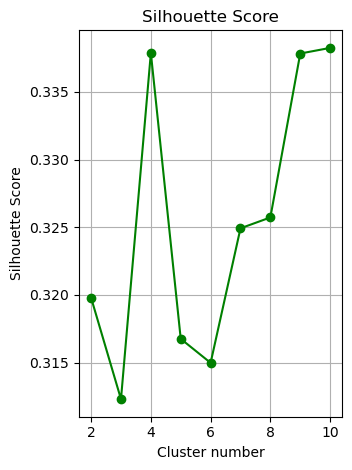

In [74]:
#Performing Agglomerative clustering 

silhouette_scores = []

k_range=range(2,11)
for k in k_range:
    agglom = AgglomerativeClustering(n_clusters=k).fit(data)
    silhouette_avg = silhouette_score(data, agglom.labels_)
    print(silhouette_avg)
    silhouette_scores.append(silhouette_avg)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score')
plt.xlabel('Cluster number')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

In [75]:
for i in range (2,11):
    agglom = AgglomerativeClustering(n_clusters=i).fit(data)
    labels=agglom.labels_
    db_index = metrics.davies_bouldin_score(data, labels)
    print("Davies-Bouldin Index for "+str(i) +" groups:", db_index)
    ch_index=metrics.calinski_harabasz_score(data, labels)
    print("Calinski-Harabasz Index for "+str(i)+" groups:", ch_index)

Davies-Bouldin Index for 2 groups: 1.2339898812731689
Calinski-Harabasz Index for 2 groups: 24.95045385542815
Davies-Bouldin Index for 3 groups: 1.0533394450173552
Calinski-Harabasz Index for 3 groups: 26.56880010566551
Davies-Bouldin Index for 4 groups: 0.9619325762585982
Calinski-Harabasz Index for 4 groups: 31.47577477822254
Davies-Bouldin Index for 5 groups: 0.8726595684875539
Calinski-Harabasz Index for 5 groups: 28.315606268046686
Davies-Bouldin Index for 6 groups: 0.9518442360805092
Calinski-Harabasz Index for 6 groups: 27.68595320624777
Davies-Bouldin Index for 7 groups: 0.9287956661303974
Calinski-Harabasz Index for 7 groups: 29.02481541850211
Davies-Bouldin Index for 8 groups: 0.9230853470287379
Calinski-Harabasz Index for 8 groups: 29.37000252532542
Davies-Bouldin Index for 9 groups: 0.8642504324460051
Calinski-Harabasz Index for 9 groups: 28.92625522119094
Davies-Bouldin Index for 10 groups: 0.8314020731122509
Calinski-Harabasz Index for 10 groups: 28.793893632819707
